In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

DATASET

In [33]:
df=pd.read_csv("Salary Data.csv")

In [34]:
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


SCATTER PLOT

Text(0, 0.5, 'Salary')

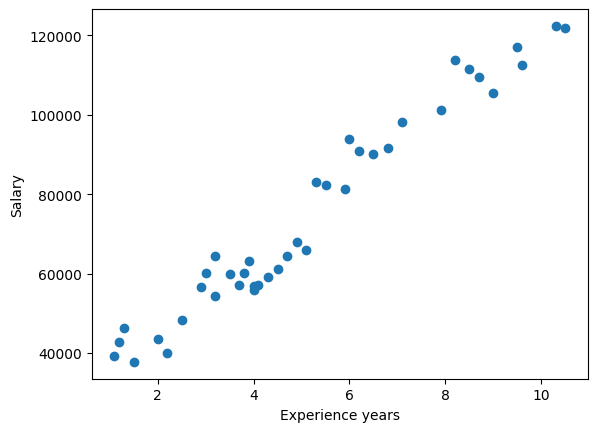

In [35]:
%matplotlib inline
plt.scatter(df['Experience Years'],df['Salary'])
plt.xlabel("Experience years")
plt.ylabel("Salary")

Training the Model

In [36]:
from sklearn.model_selection import train_test_split


In [37]:
X=df[['Experience Years']]
y=df['Salary']

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

Standarisation 

In [39]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [40]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [41]:
X_train

array([[-0.50246549],
       [ 1.03165787],
       [ 1.33099901],
       [-0.80180663],
       [-0.39021256],
       [ 0.13363444],
       [-1.51274185],
       [ 1.25616373],
       [-1.10114778],
       [-0.61471842],
       [-1.47532421],
       [ 0.6200638 ],
       [-0.09087142],
       [-1.43790657],
       [ 0.73231673],
       [ 1.63034016],
       [-1.36307128],
       [ 1.44325194],
       [ 0.05879915],
       [ 1.1439108 ],
       [-0.72697135],
       [-0.01603613],
       [-0.31537728],
       [-0.1657067 ],
       [-0.83922428],
       [-0.46504785],
       [ 0.50781087],
       [ 1.9296813 ]])

trained model using Linear Reggression

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Salary')

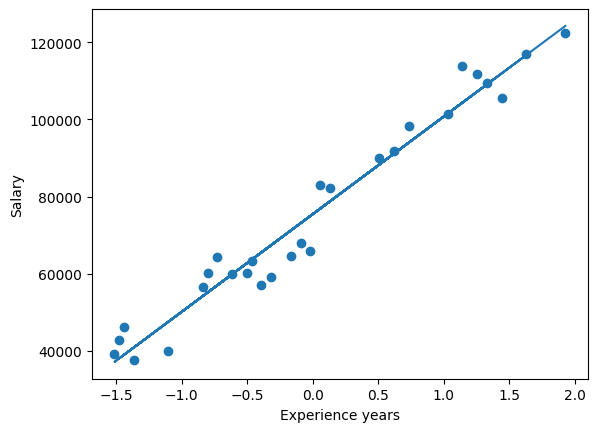

In [44]:
%matplotlib inline
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train))
plt.xlabel("Experience years")
plt.ylabel("Salary")

In [45]:
model.coef_

array([25280.47943938])

In [46]:
model.intercept_

np.float64(75416.00000000001)

Prediction
Y_pred=25280.47943938* X_test +75416.00000000001

In [47]:
y_pred=model.predict(X_test)

Finding MSE, MAE,RMSE

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [49]:
MSE=mean_squared_error(y_test,y_pred)
MAE=mean_absolute_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print(MSE)
print(MAE)
print(RMSE)  #answer is 6–10% of the salary value

35344480.17477042
5211.981371554569
5945.122385180176


Check the Accuracy usind R_square

In [50]:
from sklearn.metrics import r2_score

In [51]:
r=r2_score(y_test,y_pred)
r

0.9439054952900566

In [52]:
adjusted_r=(1 - ((1 - r**2) * (len(y_test) - 1)) / (len(y_test) - X_test.shape[1] - 1))
adjusted_r #not needed in this

0.8800533424426439

predicting new data

In [53]:
model.predict(sc.transform([[10]]))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([121361.46059775])